In [10]:
from imports import *

In [2]:
filter = Filter(city=ap.tags.TRICITY_CITIES_LIST)

dataLoader = DataLoader(
    filters=filter
)

time = datetime.now()
print("Loading data...")
data_df = dataLoader.get_df()
print(f"Data loaded in {datetime.now() - time}")
print(data_df.shape)

Loading data...
Data loaded in 0:00:08.194485
(328048, 21)


In [14]:
# Add location column
data_df = ut.add_georef_location(data_df, ap.tags.CPCB_NODES_COORDS)

data_df.select(["lat", "lon", "location", "locationId"]).unique().sort(by='lat')

lat,lon,location,locationId
f64,f64,str,str
30.6323,76.7257,"""Sector 66B Rurka""","""48F6EE5481E0"""
30.6324,76.7244,"""Sector 66B Rurka""","""48F6EE546F34"""
30.6506,76.8446,"""Gulmohar Complex Zirakpur""","""B0A6044F16B8"""
30.6652,76.9587,"""bunga road, bunga road, Asrewa…","""8CBFEA374D10"""
30.6694,77.0861,null,"""8856A6ECB014"""
30.6738,76.8495,"""Sector 12A Kundi""","""8856A6FD31D8"""
30.6748,76.6612,"""Sector 111 Bhago Majra""","""8CBFEA375998"""
30.68,76.7439,"""Sector 64 Sahibzada Ajit Singh…","""8856A6EF2984"""
30.6812,76.7179,"""Sector 68 Sahibzada Ajit Singh…","""8856A6FD43CC"""


In [4]:
df = data_df.clone()

import utils as ut

df = ut.convert_units_and_calculate_subindicies(df)
df = ut.calculate_aqi_metrics(df)

df.head()

['AQI_CO_MGM3', 'AQI_CO_PPM', 'AQI_NO2_PPB', 'AQI_NO2_UGM3', 'AQI_O3_PPB', 'AQI_O3_UGM3', 'AQI_PM10_UGM3', 'AQI_PM2_5_UGM3', 'AQI_SO2_PPB', 'AQI_SO2_UGM3']


scrape_id,lat,lon,locationId,city,state,country,last_updated,AQI_IN,AQI_US,CO_PPB,NO2_PPB,O3_PPB,SO2_PPB,PM1_UGM3,PM2_5_UGM3,PM10_UGM3,H_PERCENT,T_C,TVOC_PPM,Noise_DB,location,NO2_UGM3,O3_UGM3,SO2_UGM3,CO_MGM3,CO_PPM,NO2_PPB_24h_subindex,NO2_UGM3_24h_subindex,O3_PPB_8h_subindex,O3_UGM3_8h_subindex,SO2_PPB_24h_subindex,SO2_UGM3_24h_subindex,CO_PPM_8h_subindex,CO_MGM3_8h_subindex,PM2_5_UGM3_24h_subindex,PM10_UGM3_24h_subindex,AQI_NO2_PPB,AQI_NO2_UGM3,AQI_O3_PPB,AQI_O3_UGM3,AQI_SO2_PPB,AQI_SO2_UGM3,AQI_CO_PPM,AQI_CO_MGM3,AQI_PM2_5_UGM3,AQI_PM10_UGM3,AQI_CPCB,AQI_SAFAR,AQI_rho
i64,f64,f64,str,str,str,str,datetime[μs],i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64
11557375,30.7127,76.8283,"""E4B06332EC44""","""Chandigarh""","""Chandigarh""","""India""",2026-01-25 05:05:00,127,160,null,null,null,null,41.0,68.0,87.0,59.0,10.0,0.49,62.0,"""Mani Majra Chandigarh""",null,null,null,null,null,null,null,null,null,null,null,null,null,76.25,93.692308,null,null,null,null,null,null,null,null,76,94,94,94,null
17047441,30.7494,76.6752,"""ACA70486986C""","""Sahibzada Ajit Singh Nagar""","""Punjab""","""India""",2026-02-17 16:38:00,63,107,null,null,null,null,25.0,38.0,45.0,35.0,26.6,0.35,56.0,"""Chhabra Hospital, OG Street pa…",null,null,null,null,null,null,null,null,null,null,null,null,null,128.888889,155.458333,null,null,null,null,null,null,null,null,120,137,137,137,null
7117323,30.7287,76.7819,"""8856A6FD4054""","""Chandigarh""","""Chandigarh""","""India""",2026-01-03 03:07:00,287,193,null,null,null,null,60.0,116.0,160.0,76.0,13.1,0.26,43.0,"""Sector 21 Chandigarh""",null,null,null,null,null,null,null,null,null,null,null,null,null,134.841727,186.856115,null,null,null,null,null,null,null,null,123,158,158,158,null
5238155,30.6852,76.851,"""B0A6044FC35C""","""Panchkula""","""Haryana""","""India""",2025-12-22 07:32:00,147,164,null,null,null,null,48.0,74.0,91.0,null,11.0,0.83,45.0,"""Sector 11 Panchkula""",null,null,null,null,null,null,null,null,null,null,null,null,null,150.666667,190.392593,null,null,null,null,null,null,null,null,134,160,160,160,null
13334685,30.7415,76.8064,"""ACA7049ED040""","""Chandigarh""","""Chandigarh""","""India""",2026-02-01 18:07:00,147,164,null,null,null,null,46.0,74.0,88.0,64.0,19.8,0.8,56.0,"""Sector 6 Chandigarh""",null,null,null,null,null,null,null,null,null,null,null,null,null,137.013793,169.131034,null,null,null,null,null,null,null,null,125,146,146,146,null


In [5]:
gasses_df = df.filter(
    pl.all_horizontal(
        pl.col(["CO_PPB","NO2_PPB","O3_PPB","SO2_PPB", "AQI_rho"]).is_not_null()
    )
)

locations = gasses_df.select("location").unique().get_column("location").to_list()

gasses_df.describe()

statistic,scrape_id,lat,lon,locationId,city,state,country,last_updated,AQI_IN,AQI_US,CO_PPB,NO2_PPB,O3_PPB,SO2_PPB,PM1_UGM3,PM2_5_UGM3,PM10_UGM3,H_PERCENT,T_C,TVOC_PPM,Noise_DB,location,NO2_UGM3,O3_UGM3,SO2_UGM3,CO_MGM3,CO_PPM,NO2_PPB_24h_subindex,NO2_UGM3_24h_subindex,O3_PPB_8h_subindex,O3_UGM3_8h_subindex,SO2_PPB_24h_subindex,SO2_UGM3_24h_subindex,CO_PPM_8h_subindex,CO_MGM3_8h_subindex,PM2_5_UGM3_24h_subindex,PM10_UGM3_24h_subindex,AQI_NO2_PPB,AQI_NO2_UGM3,AQI_O3_PPB,AQI_O3_UGM3,AQI_SO2_PPB,AQI_SO2_UGM3,AQI_CO_PPM,AQI_CO_MGM3,AQI_PM2_5_UGM3,AQI_PM10_UGM3,AQI_CPCB,AQI_SAFAR,AQI_rho
str,f64,f64,f64,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",146346.0,146346.0,146346.0,"""146346""","""146346""","""146346""","""146346""","""146346""",146346.0,146346.0,146346.0,146346.0,146346.0,146346.0,0.0,146346.0,146346.0,146346.0,146346.0,0.0,0.0,"""146346""",146346.0,146346.0,146346.0,146346.0,146346.0,146346.0,146346.0,146346.0,146346.0,146346.0,146346.0,146346.0,146346.0,146346.0,146346.0,145375.0,146346.0,145983.0,146346.0,146346.0,146346.0,146346.0,146346.0,146346.0,146346.0,146346.0,146346.0,146346.0
"""null_count""",0.0,0.0,0.0,"""0""","""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,146346.0,0.0,0.0,0.0,0.0,146346.0,146346.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,971.0,0.0,363.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",7.9681e6,30.722053,76.798432,null,null,null,null,"""2026-01-02 21:17:30.727317""",260.266745,207.721072,527.609487,21.784224,20.33306,3.127533,null,126.795088,167.542482,42.36029,15.467761,null,null,null,40.954341,39.852798,8.194137,0.606751,0.527609,21.849448,41.076961,20.340182,39.866756,3.113763,8.158059,0.529048,0.608405,126.848218,167.621322,21.633114,40.921651,20.259496,39.548563,3.115692,8.128586,0.478189,0.555519,116.081007,146.424781,147.400769,146.518832,191.382494
"""std""",5.5948e6,0.016819,0.037766,null,null,null,null,null,94.923368,56.397686,279.824738,16.668561,16.401483,3.161087,null,54.736715,76.400119,15.163084,5.112407,null,null,null,31.336895,32.146906,8.282047,0.321798,0.279825,14.955171,28.115722,13.879935,27.204672,1.516504,3.973241,0.254992,0.293241,45.446017,64.73207,14.538957,27.193499,13.802658,25.990733,1.541309,4.001432,0.499526,0.49691,32.989773,48.390258,47.857895,48.292342,54.780201
"""min""",635.0,30.6995,76.738598,"""-160063""","""Chandigarh""","""Chandigarh""","""India""","""2025-11-09 17:22:00""",17.0,53.0,27.0,1.0,1.0,1.0,null,0.0,14.0,8.0,5.0,null,null,"""Daria Chandigarh""",1.88,1.96,2.62,0.03105,0.027,2.0,3.76,1.0,1.96,1.151515,3.01697,0.035,0.04025,41.013889,53.513158,2.0,4.0,1.0,2.0,1.0,3.0,0.0,0.0,41.0,54.0,54.0,54.0,67.74493
"""25%""",3.242743e6,30.7058,76.7651,null,null,null,null,"""2025-12-07 16:22:00""",187.0,172.0,326.0,9.0,7.0,2.0,null,86.0,110.0,32.0,12.0,null,null,null,16.92,13.72,5.24,0.3749,0.326,9.866667,18.549333,10.288889,20.166222,2.3,6.026,0.336615,0.387108,94.837838,120.0,10.0,19.0,10.0,20.0,2.0,6.0,0.0,0.0,95.0,114.0,114.0,114.0,152.022858
"""50%""",6.838194e6,30.7199,76.7911,null,null,null,null,"""2026-01-01 15:22:00""",293.0,194.0,471.0,15.0,19.0,2.0,null,118.0,154.0,41.0,14.0,null,null,null,28.2,37.24,5.24,0.54165,0.471,16.574627,31.160299,18.979592,37.2,2.8,7.336,0.478612,0.550404,118.555556,156.758621,16.0,31.0,19.0,37.0,3.0,7.0,0.0,1.0,113.0,138.0,139.0,138.0,183.967989
"""75%""",1.2052799e7,30.7356,76.835,null,null,null,null,"""2026-01-27 08:11:00""",331.0,235.0,746.0,32.0,27.0,3.0,null,160.0,213.0,50.0,19.0,null,null,null,60.16,52.92,7.86,0.8579,0.746,32.647482,61.377266,26.877551,52.68,3.542254,9.280704,0.751957,0.86475,149.289655,198.708333,32.0,61.0,27.0,53.0,4.0,9.0,1.0,1.0,133.0,166.0,166.0,166.0,216.554514
"""max""",2.1172295e7,30.754603,76.87385,"""VIR4221""","""Panchkula""","""Haryana""","""India""","""2026-03-07 02:08:00""",548.0,684.0,1000.0,20

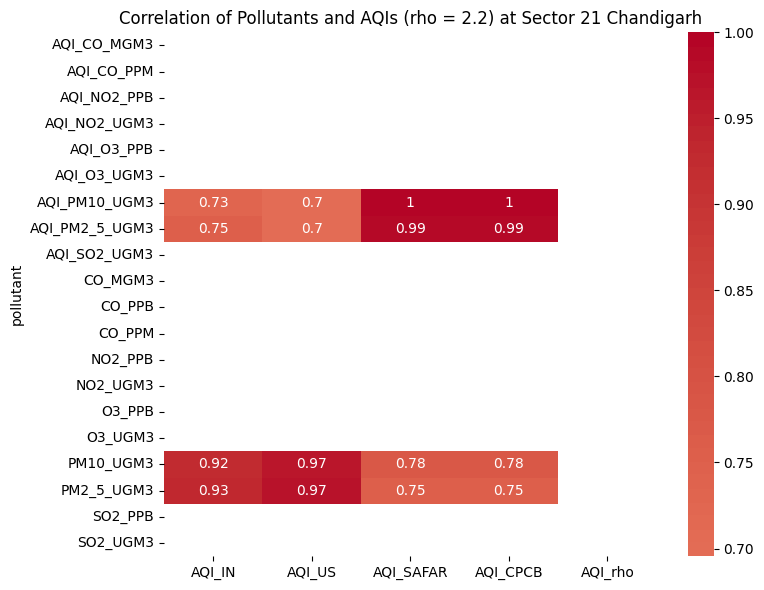

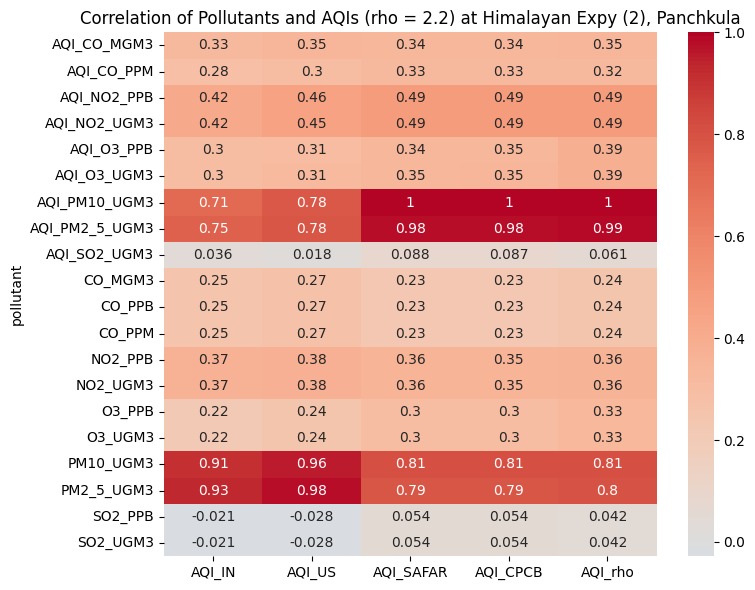

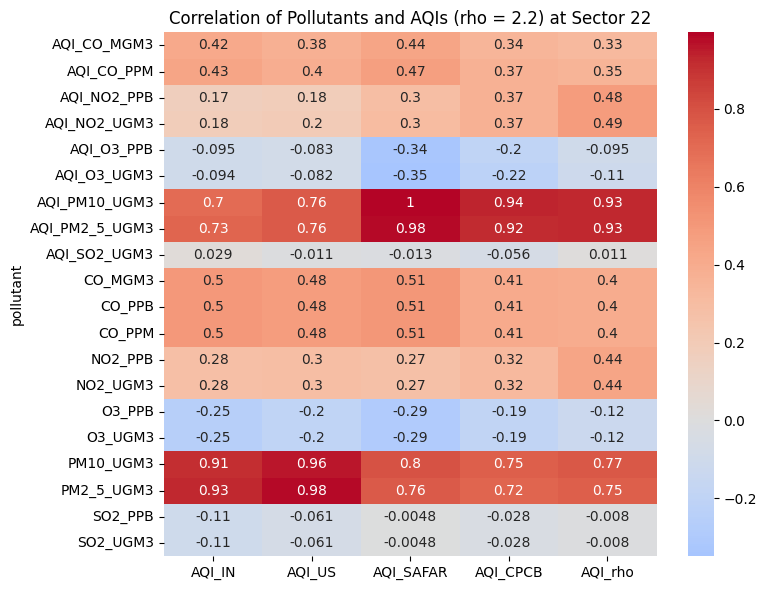

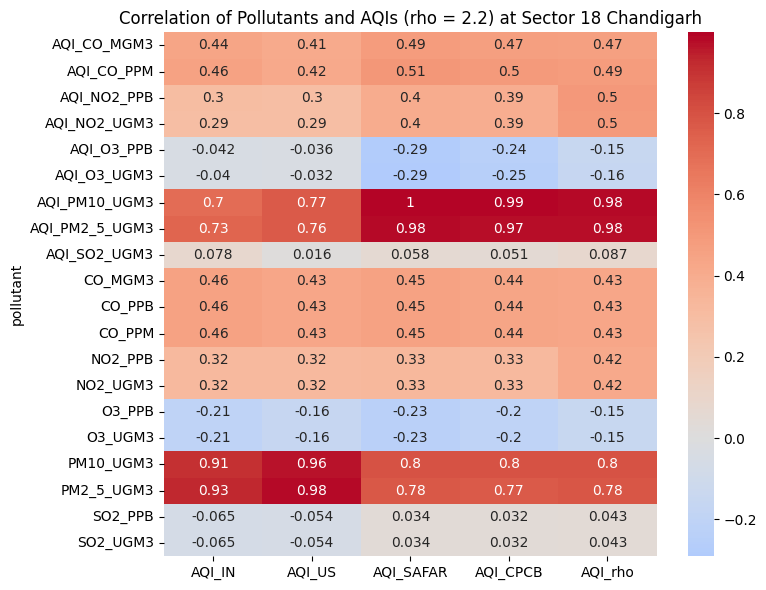

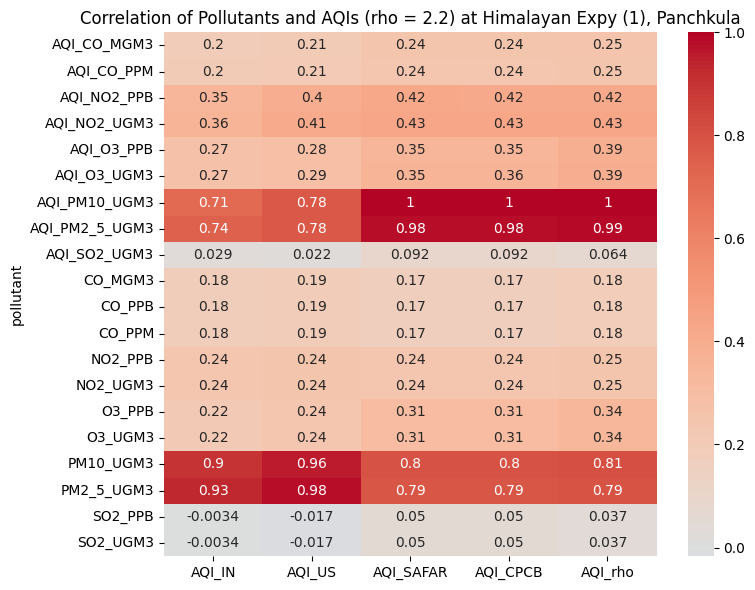

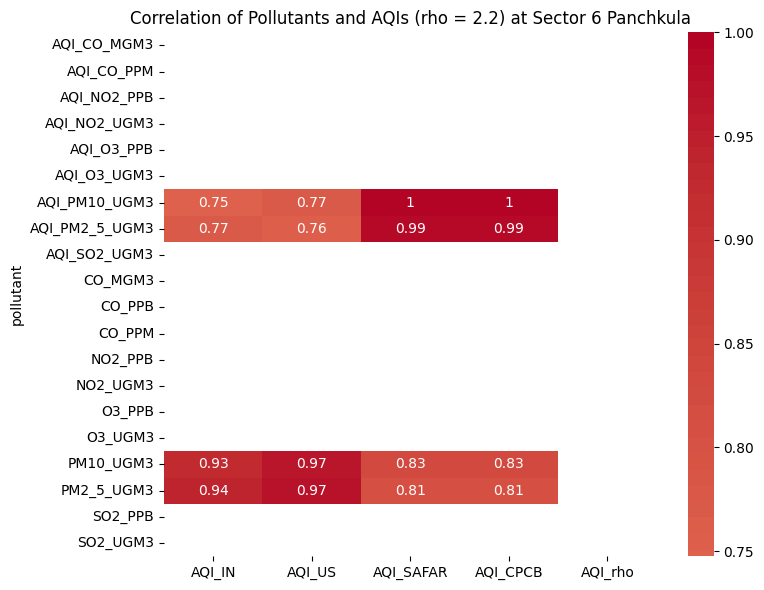

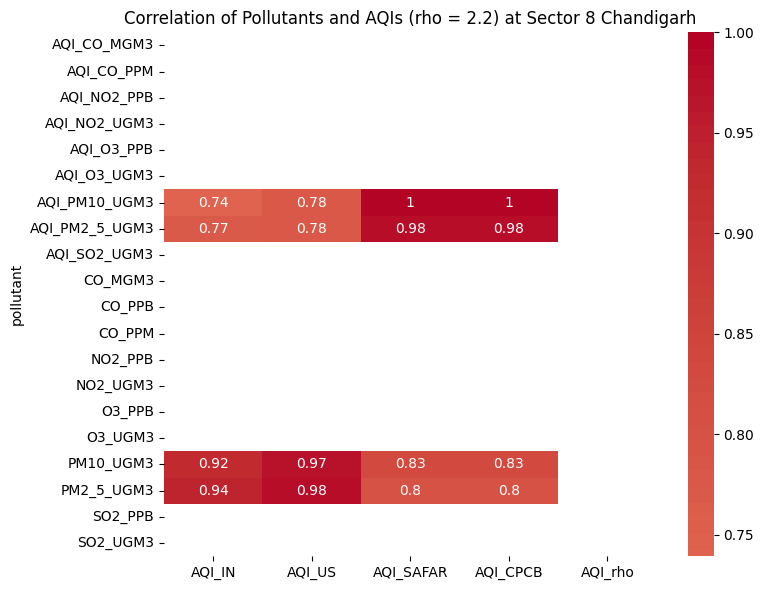

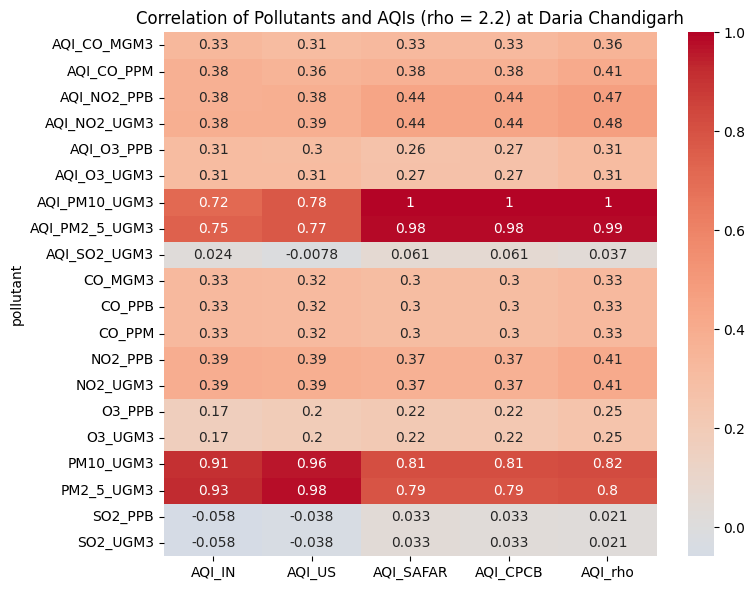

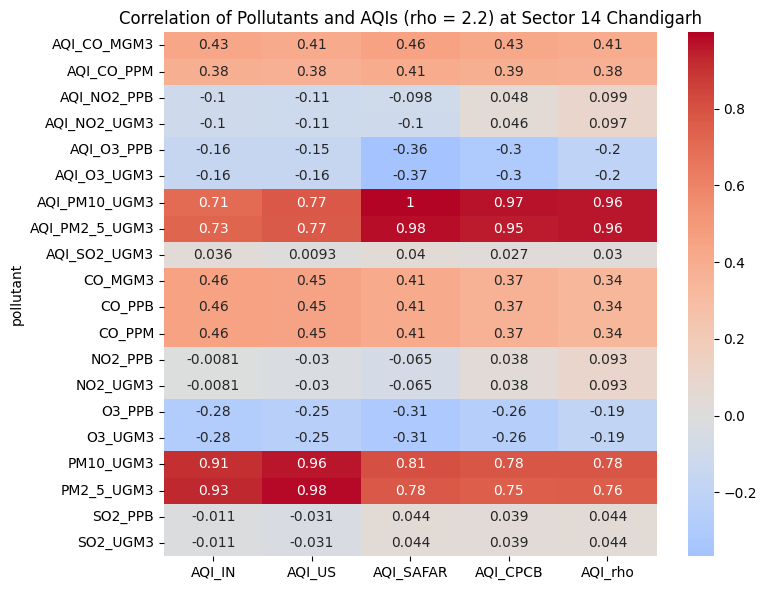

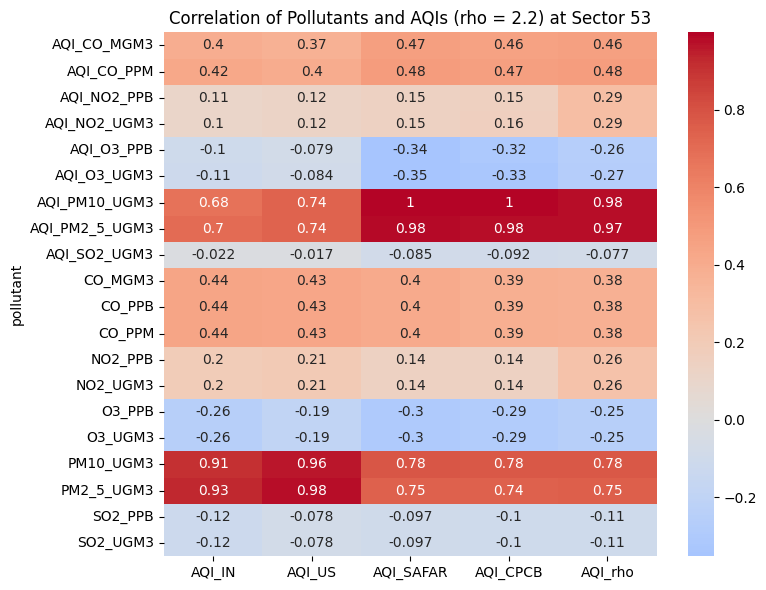

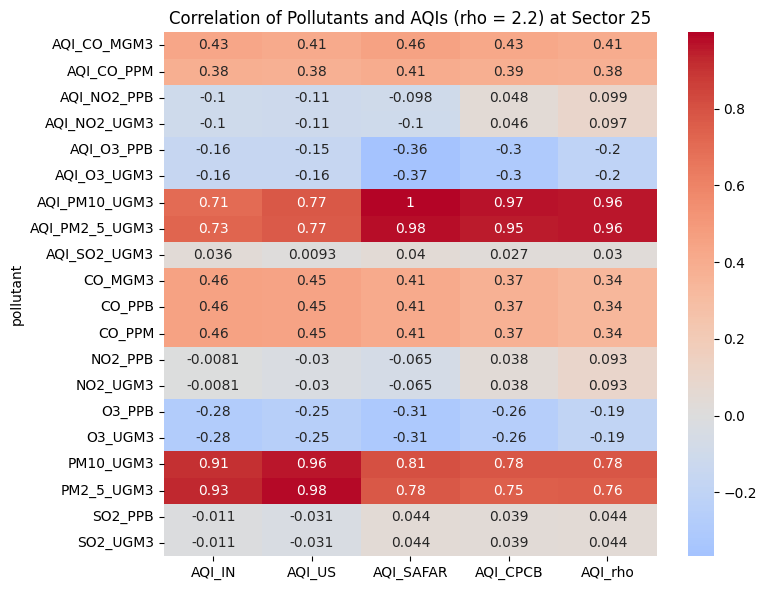

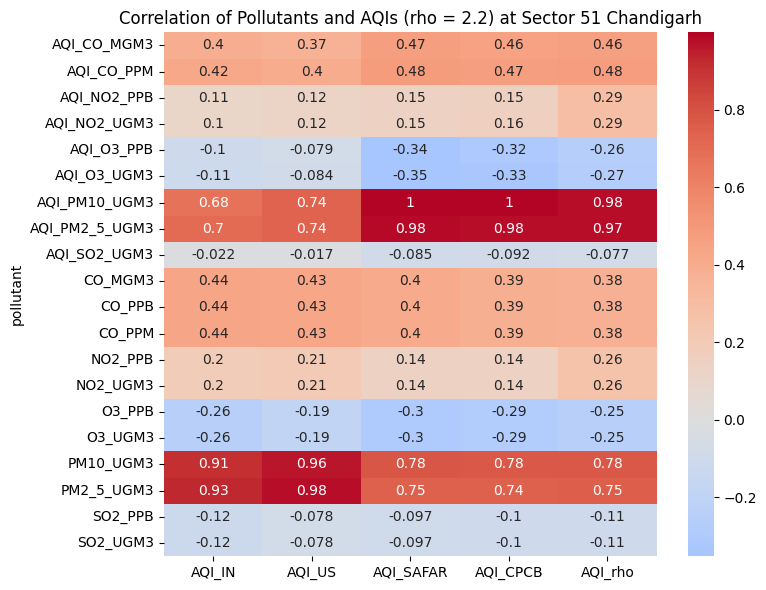

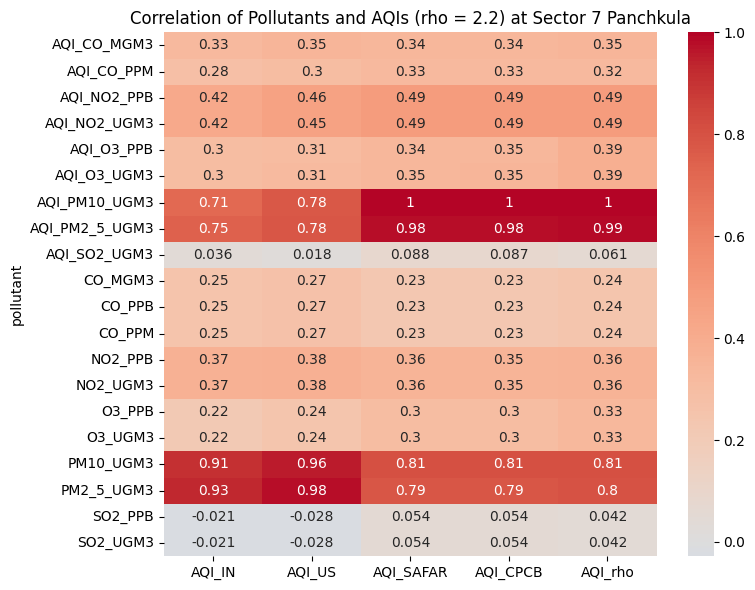

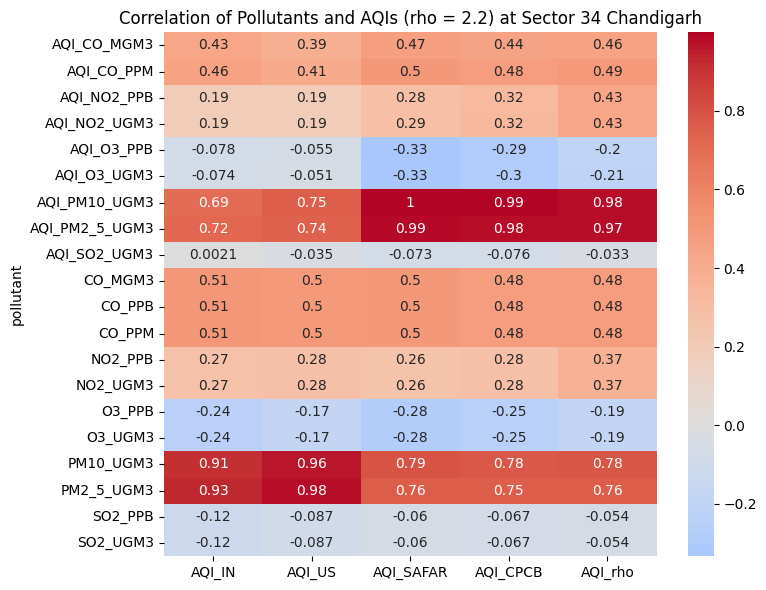

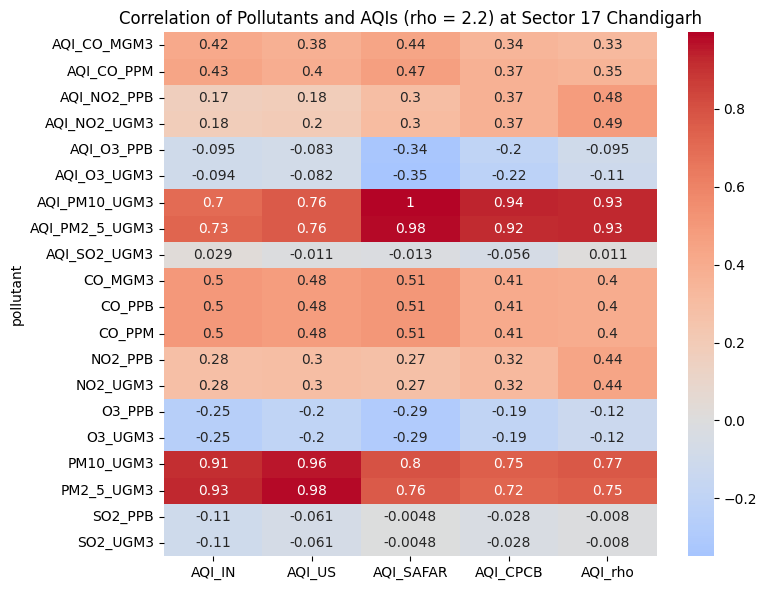

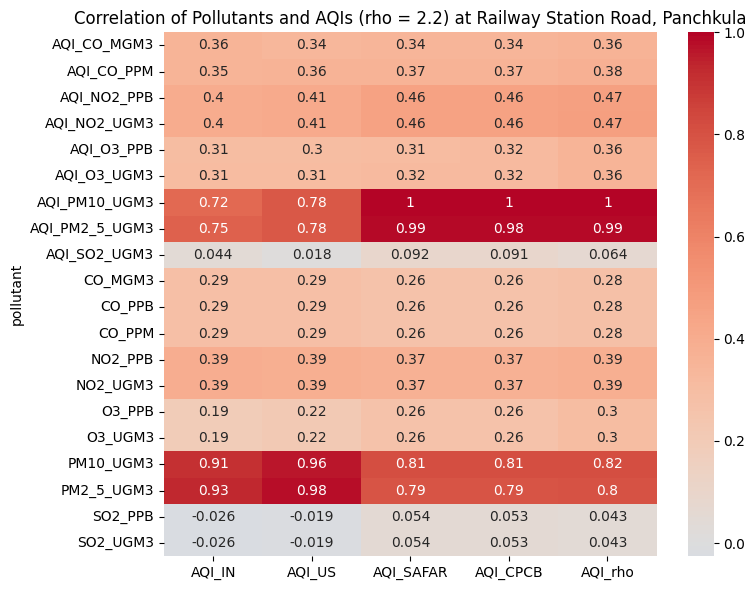

In [6]:
correlations = {}

for location in locations:
    location_df = ut.filter_by_location(df, location)
    _, corr_matrix = ut.plot_aqi_correlation_heatmap(location_df, location)
    correlations[location] = corr_matrix
    plt.show()

In [7]:
vectors = {}

for loc, corr in correlations.items():
    pdf = corr.to_pandas().set_index("pollutant").sort_index()
    vec = pdf.values.flatten()
    vectors[loc] = vec

vectors_df = pd.DataFrame.from_dict(vectors, orient="index")

normed = vectors_df.div(np.linalg.norm(vectors_df, axis=1), axis=0)
similarity = normed @ normed.T

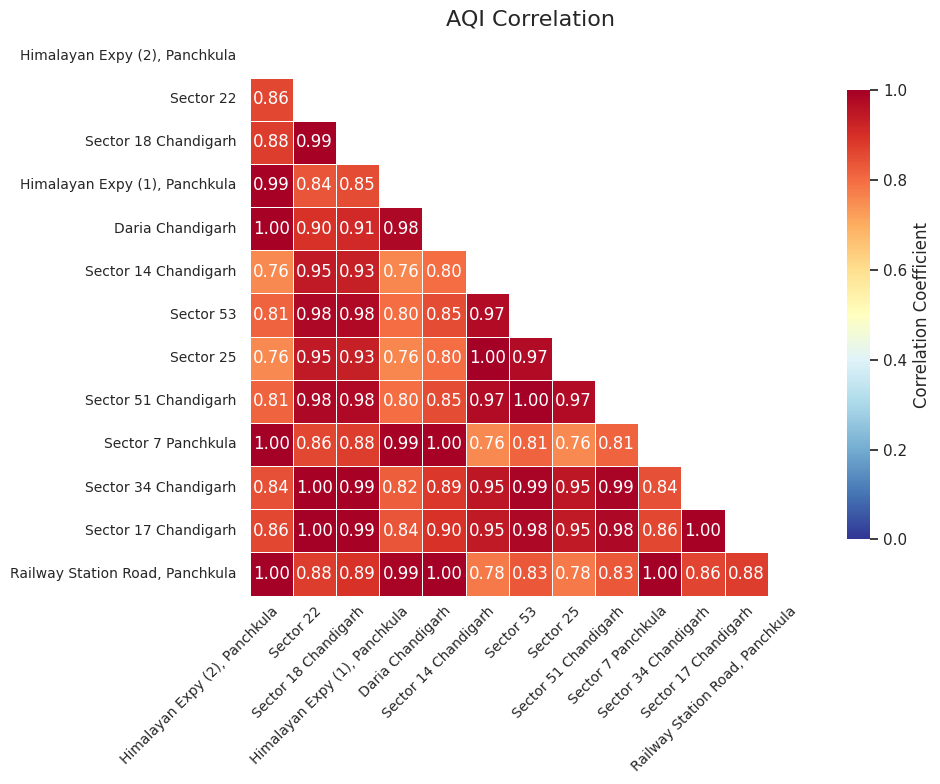

In [13]:
# Drop nulls (both rows and columns to keep it square)
similarity_clean = similarity.dropna(axis=0, how='all').dropna(axis=1, how='all')

# Create the mask for the upper triangle
mask = np.triu(np.ones_like(similarity_clean, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))

# 3. Plot using the cleaned dataframe and the mask
sns.heatmap(
    similarity_clean, 
    mask=mask,            # <--- Apply the mask here
    annot=True, 
    fmt=".2f",
    cmap="RdYlBu_r",
    vmin=0, vmax=1, 
    ax=ax,
    xticklabels=similarity_clean.index, 
    yticklabels=similarity_clean.index,
    linewidths=.5,
    square=True,          
    cbar_kws={"shrink": .8, "label": "Correlation Coefficient"}
)

# 4. Refine labels and alignment
plt.xticks(
    rotation=45, 
    ha='right', 
    rotation_mode='anchor', 
    fontsize=10
)
plt.yticks(fontsize=10)

# Remove axis titles for a cleaner look
ax.set_xlabel(None)
ax.set_ylabel(None)
ax.tick_params(axis='x', pad=0) 

ax.set_title("AQI Correlation", fontsize=16)

plt.tight_layout()
plt.show()